# **KUIS PEMBELAJARAN MESIN**

**Nama**  : Mufliha Hafsyah Shahieza <br>
**NIM**   : 244107020147 <br>
**Kelas** : TI-3G

---

# **Kmeans Manhattan & Cosine**


In [1]:
import os

DATASET_PATH = "/content/drive/MyDrive/ML/KUIS1/dataset/diabetes_012_health_indicators_BRFSS2015.csv"
OUTPUT_DIR = "output_clustering"
RANDOM_STATE = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"[CONFIG] Path dataset diatur ke: '{DATASET_PATH}'")
print(f"[CONFIG] Folder hasil output: '{OUTPUT_DIR}'")

[CONFIG] Path dataset diatur ke: '/content/drive/MyDrive/ML/KUIS1/dataset/diabetes_012_health_indicators_BRFSS2015.csv'
[CONFIG] Folder hasil output: 'output_clustering'


In [2]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, Normalizer, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
np.random.seed(RANDOM_STATE)

print("✅ Library berhasil dimuat!")

✅ Library berhasil dimuat!


In [4]:
def load_and_preprocess_data(path):
    if not os.path.exists(path):
        print(f"⚠️ File '{path}' tidak ditemukan. Membuat dataset dummy benchmark...")
        # Pastikan folder parent dibuat sebelum menyimpan file
        parent_dir = os.path.dirname(path)
        if parent_dir:
            os.makedirs(parent_dir, exist_ok=True)

        from sklearn.datasets import make_blobs
        X_b, _ = make_blobs(n_samples=500, n_features=5, centers=4, random_state=RANDOM_STATE)
        df_raw = pd.DataFrame(X_b, columns=[f"Fitur_{i+1}" for i in range(5)])
        df_raw.to_csv(path, index=False)
    else:
        print(f"📂 Membaca dataset dari: '{path}'")
        df_raw = pd.read_csv(path)

    print(f"Dimensi awal dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

    # Pembersihan metadata/kolom non-informatif
    metadata_cols = ['url', 'source', 'page', 'id', 'link', 'redundancy', 'index']
    cols_to_drop = [c for c in df_raw.columns if any(kw in c.lower() for kw in metadata_cols) or df_raw[c].nunique() <= 1]
    df_clean = df_raw.drop(columns=cols_to_drop)

    num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

    # Imputasi nilai hilang jika ada
    if len(num_cols) > 0:
        imputer = SimpleImputer(strategy='median')
        df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

    # Encoding variabel kategorikal
    low_card = [c for c in cat_cols if df_clean[c].nunique() <= 10]
    high_card = [c for c in cat_cols if df_clean[c].nunique() > 10]
    df_clean = df_clean.drop(columns=high_card)

    if len(low_card) > 0:
        df_features = pd.get_dummies(df_clean, columns=low_card, drop_first=False, dtype=float)
    else:
        df_features = df_clean.select_dtypes(include=[np.number]).astype(float)

    scaler_std = StandardScaler()
    X_std = scaler_std.fit_transform(df_features.values)
    normalizer = Normalizer(norm='l2')
    X_cosine = normalizer.fit_transform(X_std)
    scaler_manhattan = RobustScaler()
    X_manhattan = scaler_manhattan.fit_transform(df_features.values)

    return df_raw, df_features, X_cosine, X_manhattan

df_raw, df_features, X_cosine, X_manhattan = load_and_preprocess_data(DATASET_PATH)
print("✅ Preprocessing data untuk Cosine & Manhattan selesai!")

⚠️ File '/content/drive/MyDrive/ML/KUIS1/dataset/diabetes_012_health_indicators_BRFSS2015.csv' tidak ditemukan. Membuat dataset dummy benchmark...
Dimensi awal dataset: 500 baris x 5 kolom
✅ Preprocessing data untuk Cosine & Manhattan selesai!


In [5]:
class KMeansCosine:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]

        # Inisialisasi Centroid Acak
        init_idx = rng.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[init_idx].copy()

        for it in range(self.max_iter):
            # Hitung matriks Cosine Distance: d = 1 - cos(theta)
            dists = pairwise_distances(X, self.centroids, metric='cosine')
            labels = np.argmin(dists, axis=1)

            # Update Centroid: Hitung MEAN lalu Re-Normalize L2 ke permukaan unit sphere
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                pts = X[labels == k]
                if len(pts) == 0:
                    new_centroids[k] = X[rng.randint(n_samples)]
                else:
                    mean_v = np.mean(pts, axis=0)
                    norm = np.linalg.norm(mean_v)
                    new_centroids[k] = mean_v / (norm if norm > 0 else 1.0)

            # Cek konvergensi pergeseran centroid
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            self.centroids = new_centroids
            self.labels_ = labels

        # Inertia Cosine = Total Cosine Distance terdekat
        final_dists = pairwise_distances(X, self.centroids, metric='cosine')
        self.inertia_ = float(np.sum(np.min(final_dists, axis=1)))
        return self

class KMeansManhattan:
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = 0.0

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        n_samples = X.shape[0]

        # Inisialisasi Centroid Acak
        init_idx = rng.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[init_idx].copy()

        for it in range(self.max_iter):
            # Hitung matriks Manhattan Distance: d = sum(|x_i - y_i|)
            dists = pairwise_distances(X, self.centroids, metric='manhattan')
            labels = np.argmin(dists, axis=1)

            # Update Centroid: Gunakan MEDIAN (meminimalkan L1 Manhattan Distance)
            new_centroids = np.zeros_like(self.centroids)
            for k in range(self.n_clusters):
                pts = X[labels == k]
                if len(pts) == 0:
                    new_centroids[k] = X[rng.randint(n_samples)]
                else:
                    new_centroids[k] = np.median(pts, axis=0)

            # Cek konvergensi pergeseran centroid
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break
            self.centroids = new_centroids
            self.labels_ = labels

        # Inertia Manhattan = Total Manhattan Distance terdekat
        final_dists = pairwise_distances(X, self.centroids, metric='manhattan')
        self.inertia_ = float(np.sum(np.min(final_dists, axis=1)))
        return self

print("✅ Klas KMeansCosine (Spherical) dan KMeansManhattan (K-Medians) berhasil didefinisikan!")

✅ Klas KMeansCosine (Spherical) dan KMeansManhattan (K-Medians) berhasil didefinisikan!


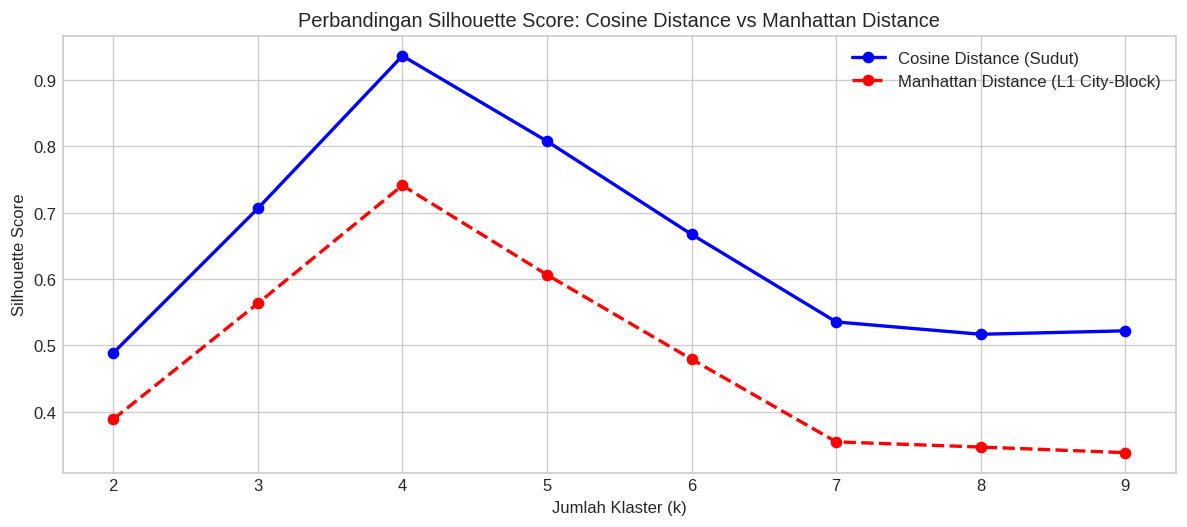

=== 🔹 TABEL EVALUASI COSINE DISTANCE ===


,k,Cosine Inertia,Silhouette Cosine,DB Index Cosine
0,2,243.060961,0.488640,0.892284
1,3,108.510592,0.706178,0.741444
2,4,17.850342,0.935919,0.347496
3,5,16.017648,0.807401,0.782375
4,6,14.949589,0.667171,1.104617
5,7,13.868094,0.535347,1.308062
6,8,13.251421,0.516776,1.276482
7,9,12.816107,0.521966,1.293169



=== 🔸 TABEL EVALUASI MANHATTAN DISTANCE ===


,k,Manhattan Inertia,Silhouette Manhattan,DB Index Manhattan
0,2,1000.199558,0.388752,0.880088
1,3,726.556896,0.563277,0.802472
2,4,356.189486,0.740900,0.400874
3,5,343.937877,0.606337,0.837534
4,6,330.862167,0.479225,1.135360
5,7,318.524102,0.354844,1.332598
6,8,311.924407,0.347004,1.374410
7,9,307.470074,0.338553,1.415951


In [6]:
K_range = range(2, 10)
res_cosine = []
res_manhattan = []

for k in K_range:

    m_cos = KMeansCosine(n_clusters=k, random_state=RANDOM_STATE).fit(X_cosine)
    d_cos = pairwise_distances(X_cosine, metric='cosine')
    s_cos = silhouette_score(d_cos, m_cos.labels_, metric='precomputed')
    db_cos = davies_bouldin_score(X_cosine, m_cos.labels_)
    res_cosine.append({'k': k, 'Cosine Inertia': m_cos.inertia_, 'Silhouette Cosine': s_cos, 'DB Index Cosine': db_cos})


    m_man = KMeansManhattan(n_clusters=k, random_state=RANDOM_STATE).fit(X_manhattan)
    d_man = pairwise_distances(X_manhattan, metric='manhattan')
    s_man = silhouette_score(d_man, m_man.labels_, metric='precomputed')
    db_man = davies_bouldin_score(X_manhattan, m_man.labels_)
    res_manhattan.append({'k': k, 'Manhattan Inertia': m_man.inertia_, 'Silhouette Manhattan': s_man, 'DB Index Manhattan': db_man})

df_res_cos = pd.DataFrame(res_cosine)
df_res_man = pd.DataFrame(res_manhattan)

# Grafik Komparasi Silhouette Score
plt.figure(figsize=(10, 4.5))
plt.plot(df_res_cos['k'], df_res_cos['Silhouette Cosine'], 'bo-', label='Cosine Distance (Sudut)', linewidth=2)
plt.plot(df_res_man['k'], df_res_man['Silhouette Manhattan'], 'ro--', label='Manhattan Distance (L1 City-Block)', linewidth=2)
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Silhouette Score')
plt.title('Perbandingan Silhouette Score: Cosine Distance vs Manhattan Distance')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_silhouette.png'))
plt.show()

print("=== 🔹 TABEL EVALUASI COSINE DISTANCE ===")
display(df_res_cos)
print("\n=== 🔸 TABEL EVALUASI MANHATTAN DISTANCE ===")
display(df_res_man)

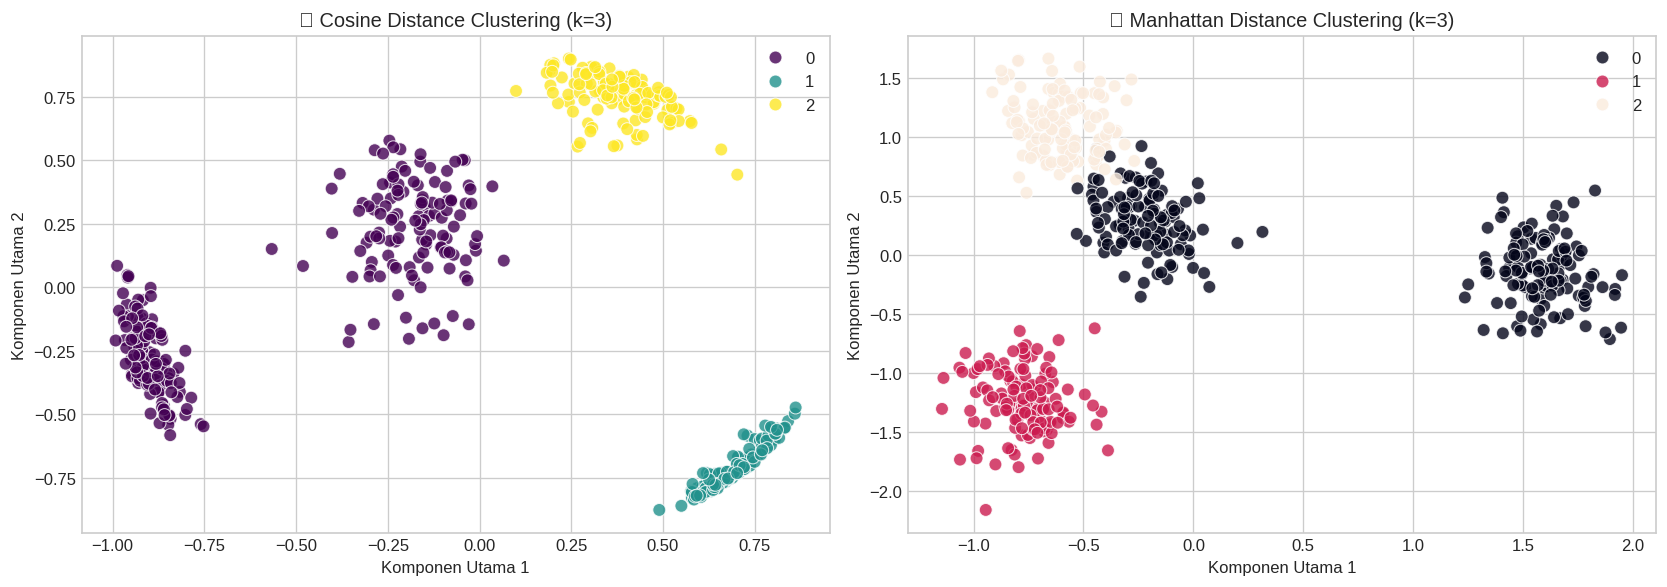

✅ Pemodelan selesai! Hasil disimpan di 'output_clustering/dataset_clustered_all.csv'


In [7]:
OPTIMAL_K = 3

# 1. Fit Model Optimal Cosine
model_cos = KMeansCosine(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE).fit(X_cosine)

# 2. Fit Model Optimal Manhattan
model_man = KMeansManhattan(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE).fit(X_manhattan)

# Simpan hasil prediksi label ke dalam DataFrame asli
df_raw['Cluster_Cosine'] = model_cos.labels_
df_raw['Cluster_Manhattan'] = model_man.labels_
df_raw.to_csv(os.path.join(OUTPUT_DIR, 'dataset_clustered_all.csv'), index=False)

# Proyeksi PCA 2D untuk Visualisasi
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_cos = pca.fit_transform(X_cosine)
X_pca_man = pca.fit_transform(X_manhattan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Hasil Clustering Cosine Distance
sns.scatterplot(ax=axes[0], x=X_pca_cos[:,0], y=X_pca_cos[:,1], hue=model_cos.labels_, palette='viridis', s=60, alpha=0.8)
axes[0].set_title(f'🔹 Cosine Distance Clustering (k={OPTIMAL_K})')
axes[0].set_xlabel('Komponen Utama 1')
axes[0].set_ylabel('Komponen Utama 2')

# Plot Hasil Clustering Manhattan Distance
sns.scatterplot(ax=axes[1], x=X_pca_man[:,0], y=X_pca_man[:,1], hue=model_man.labels_, palette='rocket', s=60, alpha=0.8)
axes[1].set_title(f'🔸 Manhattan Distance Clustering (k={OPTIMAL_K})')
axes[1].set_xlabel('Komponen Utama 1')
axes[1].set_ylabel('Komponen Utama 2')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cluster_comparison_pca.png'))
plt.show()

print(f"✅ Pemodelan selesai! Hasil disimpan di '{OUTPUT_DIR}/dataset_clustered_all.csv'")